# Homework meeting 1

Below you will find the necessry imported pachages

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

Below you'll find a small test to see if the tables uploaded properly

In [65]:
df_A24 = pd.read_excel('/home/marius/Documents/code/Vs/python/Scientific_computing/W1/data/Maastricht_August_2024.xlsx')
df_A25 = pd.read_excel('/home/marius/Documents/code/Vs/python/Scientific_computing/W1/data/Maastricht_August_2025.xlsx')
df_J24 = pd.read_excel('/home/marius/Documents/code/Vs/python/Scientific_computing/W1/data/Maastricht_July_2024.xlsx')
df_J25 = pd.read_excel('/home/marius/Documents/code/Vs/python/Scientific_computing/W1/data/Maastricht_July_2025.xlsx')

print(df_A24.head(1))
print(df_A25.head(1))
print(df_J24.head(1))
print(df_J25.head(1))


   Day  Max_Temp  Max_Dewpoint  Avg_Humidity  Avg_Pressure
0    1        22            20          94.0         998.3
   Day  Max_Temp  Max_Dewpoint  Avg_Humidity  Avg_Pressure
0    1        21            17          86.5         998.8
   Day  Max_Temp  Max_Dewpoint  Avg_Humidity  Avg_Pressure
0    1        19            16          77.8        1001.8
   Day  Max_Temp  Max_Dewpoint  Avg_Humidity  Avg_Pressure
0    1        37            18          46.3        1001.6


Now we will start with the tasks:

## Task 1:

Highest temperature in July 2025: 39
Mean dew point in July 2025: 15.548387096774194
Standard deviation of the temperature in July 2025: 4.199995044841238


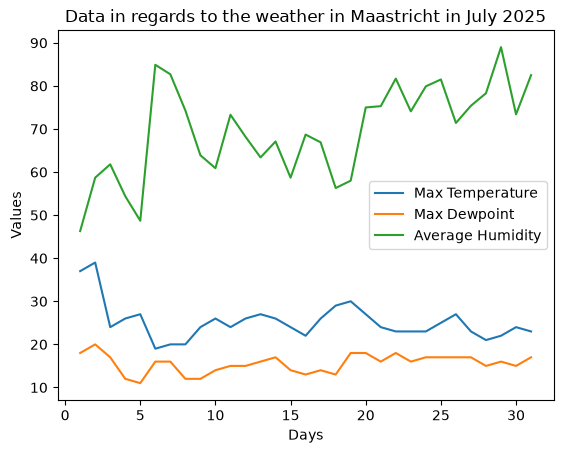

In [66]:
# Prints the asked points
print(f"Highest temperature in July 2025: {max(df_J25.Max_Temp)}")
print(f"Mean dew point in July 2025: {sum(df_J25.Max_Dewpoint)/len(df_J25.Max_Dewpoint)}")
print(f"Standard deviation of the temperature in July 2025: {np.std(df_J25.Max_Temp)}")

plt.title("Data in regards to the weather in Maastricht in July 2025")
plt.plot(df_J25.Day, df_J25.Max_Temp)
plt.plot(df_J25.Day, df_J25.Max_Dewpoint)
plt.plot(df_J25.Day, df_J25.Avg_Humidity)
# plt.plot(df_J25.Day, df_J25.Avg_Pressure)
plt.xlabel("Days")
plt.ylabel("Values")
plt.legend(["Max Temperature", "Max Dewpoint", "Average Humidity"])

## Task 2:

Average Humidex in July 2025: 29.59190040025788


Text(0, 0.5, 'Humidex')

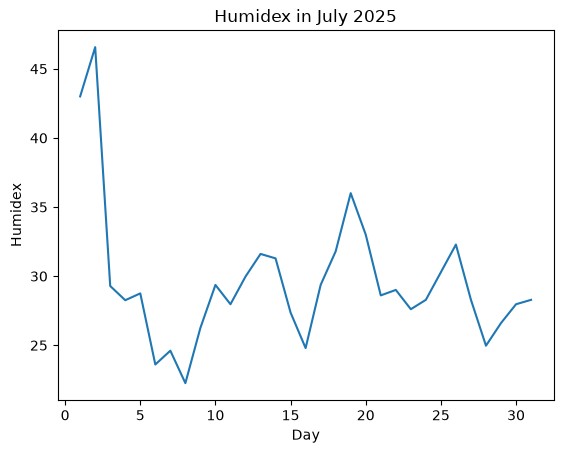

In [67]:
# Gettign Euler's number
from math import e

# Making the function equation found on: https://en.wikipedia.org/wiki/Humidex
def humidex(temperature, dewpoint):
    a = 6.11 * e ** (5417.7530 * ((1 / 273.16) - (1 / (dewpoint + 273.15))))
    h = temperature + 0.5555 * (a - 10)
    return h

# Prints the averager Humidex in July 2025
print(f"Average Humidex in July 2025: {sum(humidex(df_J25.Max_Temp, df_J25.Max_Dewpoint))/len(humidex(df_J25.Max_Temp, df_J25.Max_Dewpoint))}")

# Plots a table with the Humidex in July 2025
plt.title("Humidex in July 2025")
plt.plot(df_J25.Day, humidex(df_J25.Max_Temp, df_J25.Max_Dewpoint))
plt.xlabel("Day")
plt.ylabel("Humidex")

## Task 3

Here as we will use the five-day sliding window average anyway I combined point 1 and 2 in one box of code

In [68]:
# The code is based on the example from: https://www.geeksforgeeks.org/python/how-to-calculate-moving-averages-in-python/

# First we take the array from  humidex and make it a list so we can append things in the future to it
arr = list(humidex(df_J25.Max_Temp, df_J25.Max_Dewpoint))
# We make a variable with the number of steps for average
window_size = 5
i = 0

# Make the list for the averages
moving_averages = []
# Make a new list for the predictions for August
new_data=[]

# remembers the starting number of objects in the list
ln=len(arr)

# The while loop that stops at the 10th of August 
# it is 5, not 10, because the normal system by default would have stoped 5 steps before ln
# this happens because you want to average over 5 numbers each time but the extremities
# do not have number to their left or right so the average would not be of 5 numbers anymore
while i < ln+5:

    window = arr[i : i + window_size] # takes the indexes for the numbers in the average
    window_average = round(sum(window) / window_size, 2) # makes the average
    moving_averages.append(window_average) # appends to the list overages

     # after the humidex list ends we need to also start adding the averages to it
     # this will let us continue the average taking
    if len(arr)-window_size==i:
        arr.append(window_average)
        new_data.append(window_average)
    i += 1
nt=new_data

In [69]:
# Prints the desired number and it compares it to the actual data
print(f"Prediction 10 August 2025: {new_data[9]}")
print(f"The actual number observed: {list(humidex(df_A25.Max_Temp, df_A25.Max_Dewpoint))[9]}")

Prediction 10 August 2025: 27.42
The actual number observed: 30.365374268474604


In [70]:
# numpy needs array to work from what I understand so we need to change the data from
# the humidex into an array
real = np.array(humidex(df_A25.Max_Temp, df_A25.Max_Dewpoint))[:10]

# function to solve the average absolute prediction error
# formula from: https://www.datacamp.com/tutorial/mean-absolute-error
mae = np.mean(np.abs(real - new_data))


print(f"The average absolute prediction error: {mae}")

The average absolute prediction error: 1.8354470388856925


As you can see below the error is of around 7% which I think is a small enought error to be able to make some predictions. Of course there are much better methods as a combination of different sliding window based systems and of course more data on different years should as well help such predictions.

In [71]:
print((mae/new_data[9])*100)

6.693825816505078


## Task 4

After trying different methods as adding diffrent lenght sliding window averages I found out that, for this set of data specifically, the best way I is to take a 30-day sliding window average. Of course this is data specific and I consider that probably the system below is the best overall even if for this system specifically it is not enought. I find that Tapered Moving Average (https://people.duke.edu/~rnau/Notes_on_forecasting_with_moving_averages--Robert_Nau.pdf, pg. 7) is probably a good and simple (without exponential smoothing or any other crazy stuff) method:

$$\langle Y_{t+1} \rangle=\frac{
    \frac{1}{3}\left(\frac{1}{2}Y_t+Y_{t-1}+Y_{t-3}+\frac{1}{2}Y_{t-4}\right) +Y_{t-2}
    }{2}$$

As you can see the method used by me goes a step more and makes the tampering harder which resulted in a minimal improvment.

In [72]:

# To be able to keep the data in an orderly way I makw this list
prediction_list=[]

# To be able to go through different sizes of windows I made an if function

for j in [5,7,30]:
    arr = list(humidex(df_J25.Max_Temp, df_J25.Max_Dewpoint))
    window_size = j

    # Make the list for the averages
    moving_averages = []
    # Make a new list for the predictions for August
    new_data=[]

    # remembers the starting number of objects in the list
    ln=len(arr)
    i=0
    # ln+10-window_size we have this line for the while because we want the same number of objects in each list 
    while i < ln+10-window_size:
        window = arr[i : i + window_size] # takes the indexes for the numbers in the average

        sume=(window[0]+window[-1])/2 # calculates the average of the ends average giving the desired form of Tapered Moving Average 
        sume_more=(sume+window[1]+window[window_size-2])/3 # the average for the next step in the middle
        window_average = round((sum(window[2:window_size-2])+sume_more)/ (window_size-3),2)# solves the full average
        moving_averages.append(window_average) # appends to the list overages

         # after the humidex list ends we need to also start adding the averages to it
         # this will let us continue the average taking
        if len(arr)-window_size==i:
            arr.append(window_average)
            new_data.append(window_average)
        i += 1
    # Here we append each prediction so to use them later
    prediction_list.append(new_data)

In [73]:
# here we add the predictions together
# We need to create this array such to add the lists together and then average them 
prediction_sum=np.array([0,0,0,0,0,0,0,0,0,0])
for i in range(len(prediction_list)):
    prediction_sum=prediction_sum+np.array(prediction_list[i])

prediction_sum=prediction_sum/len(prediction_list)


In [74]:
# here, to be able to test the accuracy of the system for more then one data point we use 
# the all 10 predictions from August. Here we will subtract each system, then apply absolute
# value and add each term together. This will show the total added error over the 10 days

n1=prediction_sum - np.array(humidex(df_A25.Max_Temp, df_A25.Max_Dewpoint))[:10]

# this one takes the predictions form length 30 alone
n2=np.array(new_data) - np.array(humidex(df_A25.Max_Temp, df_A25.Max_Dewpoint))[:10]
# the old predictions
n3=np.array(nt) - np.array(humidex(df_A25.Max_Temp, df_A25.Max_Dewpoint))[:10]

# prints the data
print('Each error:')
print(n1)
print(n2)
print(n3)
print('\n')
print('Total error:')
print(f'Total prediction error for the prefered system: {sum(abs(n1))}')
print(f'Total prediction error for lenght 30 alone: {sum(abs(n2))}')
print(f'Total prediction error for the old system: {sum(abs(n3))}')



Each error:
[ 1.35645512  3.0844569   0.92766262 -3.14164505  0.64978845  2.19715364
 -0.7961797  -1.24687822 -2.5455431  -2.31537427]
[ 2.37312178  3.93112357  1.55099595 -2.35497839  1.48312178  3.1838203
  0.3138203  -0.12687822 -1.40887643 -1.18537427]
[ 0.93312178  2.40112357  0.45099595 -3.42497839  0.21312178  1.5538203
 -1.4261797  -1.84687822 -3.15887643 -2.94537427]


Total error:
Total prediction error for the prefered system: 18.26113705552359
Total prediction error for lenght 30 alone: 17.912110995110744
Total prediction error for the old system: 18.354470388856925


One could considered that this total prediction error is does not fully show the trugth as the number also should depend on the initial. For this we show here the error in percentage.

In [75]:
# Calculating the procentage
f1=100 * abs(n1) / np.array(humidex(df_A25.Max_Temp, df_A25.Max_Dewpoint))[:10]
f2=100 * abs(n2) / np.array(humidex(df_A25.Max_Temp, df_A25.Max_Dewpoint))[:10]
f3=100 * abs(n3) / np.array(humidex(df_A25.Max_Temp, df_A25.Max_Dewpoint))[:10]

# printing it:
print(f1)
print(f2)
print(f3)


print(f'Total prediction error in percentage for the prefered system: {sum(f1)}')
print(f'Total prediction error in percentage for lenght 30 alone: {sum(f2)}')
print(f'Total prediction error in percentage for the old system: {sum(f3)}')

[ 5.16019858 12.53392008  3.43973628 10.13271164  2.38132206  8.51736056
  2.7648796   4.25746372  8.31635589  7.62504769]
[ 9.02778095 15.97441306  5.75103162  7.59548469  5.43529301 12.34221633
  1.08979839  0.43322547  4.60283615  3.9037038 ]
[ 3.54976265  9.75714425  1.67227514 11.04654338  0.78104128  6.02345123
  4.95266981  6.30616279 10.32013193  9.69977924]
Total prediction error in percentage for the prefered system: 65.12899609493479
Total prediction error in percentage for lenght 30 alone: 66.15578346709546
Total prediction error in percentage for the old system: 64.10896168092512
